In [1]:
# Load packages 
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
import os
import torch
import sys 

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
print("CUDA device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No CUDA device found")

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

float_type = {"device": device, "dtype": torch.float}
torch.set_default_tensor_type("torch.FloatTensor" if device.type == "cpu" else "torch.cuda.FloatTensor")

# Import utility functions - simple direct import
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/')
from utils import load_model

EASYSCI_AD = "/gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/EasySci/easysci_adata_leafletFA_K27_param_1.h5ad"

# Input/Output paths - all these need to be parameters from the command line or it's fine to just edit here with human paths
BASE_DIR = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION"
ATSE_ANNDATA_PATH = f"{BASE_DIR}/MODEL_INPUT/052025/MOUSE_SPLICING_FOUNDATION_Anndata_ATSE_counts_with_waypoints_20250519_172401.h5ad"
ATSE_FILE_PATH = f"{BASE_DIR}/ATSE_mapper/ATSE_files/MOUSE_FOUNDATION_ATSE_FILE_unanno_also_2025-04-26_19-55-26.txt.gz"

Torch version: 2.4.1.post300
CUDA available: False
CUDA device count: 0
CUDA device name: No CUDA device found
Using device: cpu


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/torch/__init__.py:955: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1728241823685/work/torch/csrc/tensor/python_tensor.cpp:432.)
  _C._set_default_tensor_type(t)


In [2]:
easysci_adata = ad.read_h5ad(EASYSCI_AD)


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [3]:
# -------------------------------------------------------------------------------------
# LOAD SPLICING DATA
# -------------------------------------------------------------------------------------

# Load splicing data
splice_adata = ad.read_h5ad(ATSE_ANNDATA_PATH)
print(f"Splicing data loaded: {splice_adata}")

# Load easysci data
easysci_adata = ad.read_h5ad(EASYSCI_AD)
print(f"EasySci data loaded: {easysci_adata}")

# -------------------------------------------------------------------------------------
# LOAD TRAINED LEAFLET FA MODEL
# -------------------------------------------------------------------------------------

# Load the best model that was trained on the Mouse Foundation data 
print("\n>> Extracting model parameters...")
model_home = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/Leaflet/leafletFAmodel/"
date = "2025-05-13"
param_id = 1
model_path = f"{model_home}/{date}/run_{param_id}/leafletfa_model.pkl.xz"
leaflet_model = load_model(model_path)
print(f"Leaflet model loaded: {leaflet_model}")

# Extract hyperparameters
alpha_pi = leaflet_model["alpha_pi"]
bb_conc = leaflet_model["bb_conc"]
dir_conc = leaflet_model["dir_conc"]

# Extract factor activities and usage
PHI = leaflet_model["assign_post"]
PI = leaflet_model["pi"]
PSI = leaflet_model["psi_learned"].T
K = leaflet_model["K"]

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


Splicing data loaded: AnnData object with n_obs × n_vars = 157418 × 19989
    obs: 'cell_id_index', 'age', 'cell_ontology_class', 'mouse.id', 'sex', 'subtissue', 'tissue', 'dataset', 'cell_name', 'cell_id', 'cell_clean', 'broad_cell_type', 'seqtech'
    var: 'junction_id', 'event_id', 'splice_motif', 'annotation_status', 'gene_name', 'gene_id', 'num_junctions', 'position_off_5_prime', 'position_off_3_prime', 'CountJuncs', 'non_zero_count_cells', 'non_zero_cell_prop', 'annotation_status_score', 'non_zero_cell_prop_score', 'junction_id_index'
    uns: 'pca_explained_variance_ratio'
    obsm: 'X_pca', 'phi_init_50_waypoints'
    varm: 'psi_init_50_waypoints'
    layers: 'cell_by_cluster_matrix', 'cell_by_junction_matrix', 'junc_ratio'


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


EasySci data loaded: AnnData object with n_obs × n_vars = 9921 × 15164
    obs: 'Main_cluster_name_wkmeans', 'Main_cluster_name', 'Type', 'primer', 'cell_id_index', 'broad_cell_type'
    var: 'mouse_foundation_junction_id', 'event_id', 'splice_motif', 'annotation_status', 'gene_name', 'gene_id', 'num_junctions', 'position_off_5_prime', 'position_off_3_prime', 'CountJuncs', 'junction_id_index', 'junction_id'
    uns: 'Main_cluster_name_colors', 'Type_colors', 'broad_cell_type_colors', 'neighbors', 'umap'
    obsm: 'X_leafletFA_K27', 'X_umap'
    layers: 'Cluster_Counts', 'Junction_Counts', 'cell_by_cluster_matrix', 'cell_by_junction_matrix'
    obsp: 'connectivities', 'distances'

>> Extracting model parameters...
Loading model to device: cpu
Leaflet model loaded: {'ELBO_num_particles': 5, 'K': 27, 'a': array([ 0.66801804,  0.08808304,  0.79344475,  0.22054863,  4.98022   ,
        0.19376314,  0.2055526 ,  0.16191296,  0.1332637 ,  0.18010296,
        0.06760944,  0.22486815,  0.836079

In [4]:
# Add XPHI to splice_adata
splice_adata.obsm[f"X_leafletFA_K{K}"] = PHI

In [5]:
easysci_adata.obs["SOURCE"] = "EASYSCI"
splice_adata.obs["SOURCE"] = "MOUSE_FOUNDATION"

# In easysci, cleanup index 
easysci_adata.obs.reset_index(drop=True, inplace=True)

In [6]:
easysci_adata.obs

,Main_cluster_name_wkmeans,Main_cluster_name,Type,primer,cell_id_index,broad_cell_type,SOURCE
0,Astrocytes_5xFAD_1032,Astrocytes,5xFAD,RH,0,Astrocytes,EASYSCI
1,Astrocytes_5xFAD_1109,Astrocytes,5xFAD,RH,1,Astrocytes,EASYSCI
2,Astrocytes_APOE4_TREM2_1766,Astrocytes,APOE4_TREM2,RH,2,Astrocytes,EASYSCI
3,Bergmann_glia_5xFAD_2298,Bergmann_glia,5xFAD,RH,3,Astrocytes,EASYSCI
4,Cerebellum_granule_neurons_21mo_366,Cerebellum_granule_neurons,21mo,RH,4,Neurons,EASYSCI
...,...,...,...,...,...,...,...
9916,Striatal_neurons_1_3mo_98,Striatal_neurons_1,3mo,RH,9916,Neurons,EASYSCI
9917,Striatal_neurons_1_5xFAD_1572,Striatal_neurons_1,5xFAD,RH,9917,Neurons,EASYSCI
9918,Striatal_neurons_1_5xFAD_928,Striatal_neurons_1,5xFAD,RH,9918,Neurons,EASYSCI
9919,Vascular_leptomeningeal_cells_5xFAD_103,Vascular_leptomeningeal_cells,5xFAD,RH,9919,Endothelial Cells,EASYSCI


In [7]:
splice_adata.obs

,cell_id_index,age,cell_ontology_class,mouse.id,sex,subtissue,tissue,dataset,cell_name,cell_id,cell_clean,broad_cell_type,seqtech,SOURCE
0,0,18m,basal epithelial cell of tracheobronchial tree,18_47_F,female,NaN,Trachea,TMS,A10_B000120,A10_B000120,A10_B000120,EPITHELIAL CELL,single_cell,MOUSE_FOUNDATION
1,1,3m,bulge keratinocyte,3_39_F,female,Telogen,Skin,TMS,A10_B000126,A10_B000126,A10_B000126,KERATINOCYTE,single_cell,MOUSE_FOUNDATION
2,2,3m,myeloid cell,3_38_F,female,Fat,SCAT,TMS,A10_B000127,A10_B000127,A10_B000127,MYELOID IMMUNE CELL,single_cell,MOUSE_FOUNDATION
3,3,3m,basal cell,3_56_F,female,Mammary_Gland,Mammary_Gland,TMS,A10_B000166,A10_B000166,A10_B000166,BASAL CELL,single_cell,MOUSE_FOUNDATION
4,4,18m,endothelial cell of coronary artery,18_53_M,male,RV,Heart,TMS,A10_B000169,A10_B000169,A10_B000169,ENDOTHELIAL CELL,single_cell,MOUSE_FOUNDATION
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157413,157413,2m,197_L5 IT CTX,184750,F,VISp,Brain_Non-Myeloid,AB,US-1250275_E2_S86,US-1250275_E2_S86,SRR16457632,Excitatory Neurons,single_nuclei,MOUSE_FOUNDATION
157414,157414,2m,204_L5/6 IT CTX,184756,M,VISp,Brain_Non-Myeloid,AB,US-1250275_E2_S87,US-1250275_E2_S87,SRR16457633,Excitatory Neurons,single_nuclei,MOUSE_FOUNDATION
157415,157415,2m,257_L5 PT CTX,185199,M,VISp,Brain_Non-Myeloid,AB,US-1250275_E2_S88,US-1250275_E2_S88,SRR16457635,Excitatory Neurons,single_nuclei,MOUSE_FOUNDATION
157416,157416,2m,204_L5/6 IT CTX,185200,F,VISp,Brain_Non-Myeloid,AB,US-1250275_E2_S89,US-1250275_E2_S89,SRR16457636,Excitatory Neurons,single_nuclei,MOUSE_FOUNDATION


In [8]:
# rename columns in easysci_adata, Main_cluster_name_wkmeans to cell_id, Main_cluster_name to broad_cell_type (remove previous broad_cell_type), replace "Type" with age 
easysci_adata.obs.drop(columns=["broad_cell_type"], inplace=True)
easysci_adata.obs.drop(columns=["primer"], inplace=True)

easysci_adata.obs.rename(columns={"Main_cluster_name_wkmeans": "cell_id", "Main_cluster_name": "broad_cell_type", "Type": "age"}, inplace=True)
easysci_adata.obs

,cell_id,broad_cell_type,age,cell_id_index,SOURCE
0,Astrocytes_5xFAD_1032,Astrocytes,5xFAD,0,EASYSCI
1,Astrocytes_5xFAD_1109,Astrocytes,5xFAD,1,EASYSCI
2,Astrocytes_APOE4_TREM2_1766,Astrocytes,APOE4_TREM2,2,EASYSCI
3,Bergmann_glia_5xFAD_2298,Bergmann_glia,5xFAD,3,EASYSCI
4,Cerebellum_granule_neurons_21mo_366,Cerebellum_granule_neurons,21mo,4,EASYSCI
...,...,...,...,...,...
9916,Striatal_neurons_1_3mo_98,Striatal_neurons_1,3mo,9916,EASYSCI
9917,Striatal_neurons_1_5xFAD_1572,Striatal_neurons_1,5xFAD,9917,EASYSCI
9918,Striatal_neurons_1_5xFAD_928,Striatal_neurons_1,5xFAD,9918,EASYSCI
9919,Vascular_leptomeningeal_cells_5xFAD_103,Vascular_leptomeningeal_cells,5xFAD,9919,EASYSCI


In [9]:
# in splice_adata, keep only cell_id, broad_cell_type, age, cell_id_index and SOURCE 
splice_adata.obs = splice_adata.obs[["cell_id", "broad_cell_type", "age", "cell_id_index", "SOURCE"]]
splice_adata.obs

,cell_id,broad_cell_type,age,cell_id_index,SOURCE
0,A10_B000120,EPITHELIAL CELL,18m,0,MOUSE_FOUNDATION
1,A10_B000126,KERATINOCYTE,3m,1,MOUSE_FOUNDATION
2,A10_B000127,MYELOID IMMUNE CELL,3m,2,MOUSE_FOUNDATION
3,A10_B000166,BASAL CELL,3m,3,MOUSE_FOUNDATION
4,A10_B000169,ENDOTHELIAL CELL,18m,4,MOUSE_FOUNDATION
...,...,...,...,...,...
157413,US-1250275_E2_S86,Excitatory Neurons,2m,157413,MOUSE_FOUNDATION
157414,US-1250275_E2_S87,Excitatory Neurons,2m,157414,MOUSE_FOUNDATION
157415,US-1250275_E2_S88,Excitatory Neurons,2m,157415,MOUSE_FOUNDATION
157416,US-1250275_E2_S89,Excitatory Neurons,2m,157416,MOUSE_FOUNDATION


In [10]:
easysci_adata

AnnData object with n_obs × n_vars = 9921 × 15164
    obs: 'cell_id', 'broad_cell_type', 'age', 'cell_id_index', 'SOURCE'
    var: 'mouse_foundation_junction_id', 'event_id', 'splice_motif', 'annotation_status', 'gene_name', 'gene_id', 'num_junctions', 'position_off_5_prime', 'position_off_3_prime', 'CountJuncs', 'junction_id_index', 'junction_id'
    uns: 'Main_cluster_name_colors', 'Type_colors', 'broad_cell_type_colors', 'neighbors', 'umap'
    obsm: 'X_leafletFA_K27', 'X_umap'
    layers: 'Cluster_Counts', 'Junction_Counts', 'cell_by_cluster_matrix', 'cell_by_junction_matrix'
    obsp: 'connectivities', 'distances'

In [11]:
# Extract obs and factor activity matrix
obs_mf = splice_adata.obs.copy()
obs_es = easysci_adata.obs.copy()

X_mf = splice_adata.obsm["X_leafletFA_K27"]
X_es = easysci_adata.obsm["X_leafletFA_K27"]

# Combine obs and features
combined_obs = pd.concat([obs_mf, obs_es], axis=0)
combined_X = np.vstack([X_mf, X_es])

In [12]:
combined_obs

,cell_id,broad_cell_type,age,cell_id_index,SOURCE
0,A10_B000120,EPITHELIAL CELL,18m,0,MOUSE_FOUNDATION
1,A10_B000126,KERATINOCYTE,3m,1,MOUSE_FOUNDATION
2,A10_B000127,MYELOID IMMUNE CELL,3m,2,MOUSE_FOUNDATION
3,A10_B000166,BASAL CELL,3m,3,MOUSE_FOUNDATION
4,A10_B000169,ENDOTHELIAL CELL,18m,4,MOUSE_FOUNDATION
...,...,...,...,...,...
9916,Striatal_neurons_1_3mo_98,Striatal_neurons_1,3mo,9916,EASYSCI
9917,Striatal_neurons_1_5xFAD_1572,Striatal_neurons_1,5xFAD,9917,EASYSCI
9918,Striatal_neurons_1_5xFAD_928,Striatal_neurons_1,5xFAD,9918,EASYSCI
9919,Vascular_leptomeningeal_cells_5xFAD_103,Vascular_leptomeningeal_cells,5xFAD,9919,EASYSCI


In [13]:
# PCA/UMAP
from sklearn.decomposition import PCA
import umap
import umap

# Direct UMAP
reducer = umap.UMAP(n_neighbors=15, min_dist=0.3, metric="euclidean", random_state=42)
X_umap = reducer.fit_transform(combined_X)
print(f"Done with UMAP!")

combined_obs["UMAP1"] = X_umap[:, 0]
combined_obs["UMAP2"] = X_umap[:, 1]

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


Done with UMAP!


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_umap(df, color_by):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df, x="UMAP1", y="UMAP2", hue=color_by, s=5, alpha=0.5)
    plt.title(f"UMAP of LeafletFA K=27 colored by {color_by}")
    plt.legend(markerscale=2, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

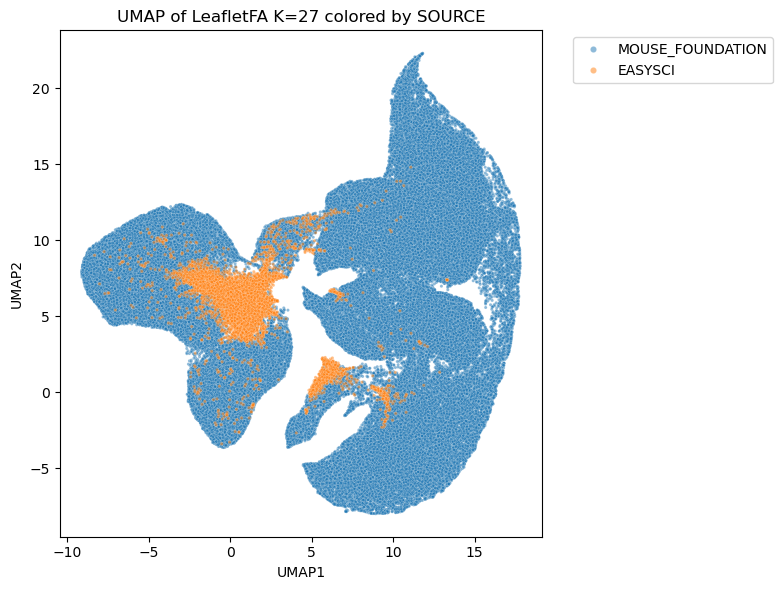

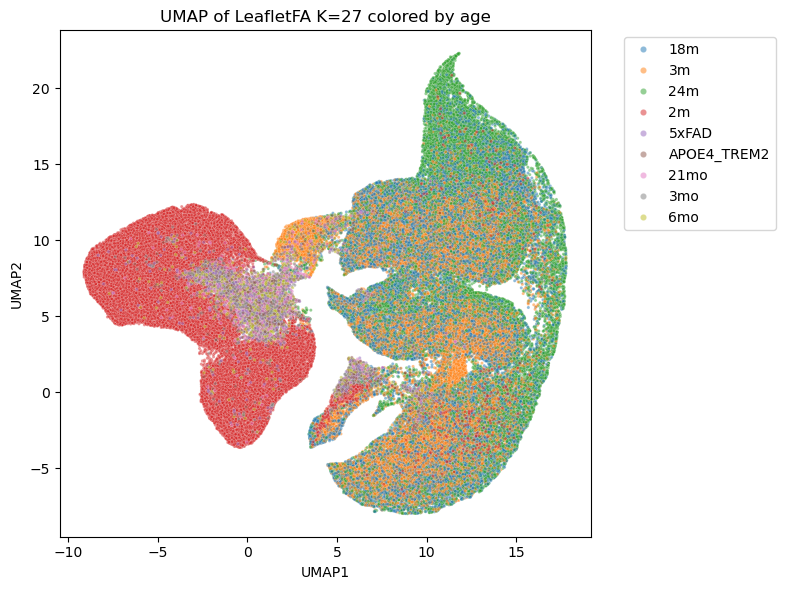

In [15]:
plot_umap(combined_obs, "SOURCE")
plot_umap(combined_obs, "age")


In [16]:
# Find celltypes that only have "neuron" or "Neuron" in the broad_cell_type column
combined_obs[combined_obs["broad_cell_type"].str.contains("neuron") | combined_obs["broad_cell_type"].str.contains("Neuron")]
combined_obs["CellFilter"] = ""
# Label the neuron containing celltypes as "Neuron"
combined_obs.loc[combined_obs["broad_cell_type"].str.contains("neuron") | combined_obs["broad_cell_type"].str.contains("Neuron"), "CellFilter"] = "Neuron"
# Label the non-neuron containing celltypes as "Non-Neuron"
combined_obs.loc[~combined_obs["broad_cell_type"].str.contains("neuron") & ~combined_obs["broad_cell_type"].str.contains("Neuron"), "CellFilter"] = "Non-Neuron"
combined_obs

,cell_id,broad_cell_type,age,cell_id_index,SOURCE,UMAP1,UMAP2,CellFilter
0,A10_B000120,EPITHELIAL CELL,18m,0,MOUSE_FOUNDATION,11.299564,5.515938,Non-Neuron
1,A10_B000126,KERATINOCYTE,3m,1,MOUSE_FOUNDATION,11.826104,2.873961,Non-Neuron
2,A10_B000127,MYELOID IMMUNE CELL,3m,2,MOUSE_FOUNDATION,14.704018,10.088587,Non-Neuron
3,A10_B000166,BASAL CELL,3m,3,MOUSE_FOUNDATION,11.607841,0.994850,Non-Neuron
4,A10_B000169,ENDOTHELIAL CELL,18m,4,MOUSE_FOUNDATION,13.676064,-3.660805,Non-Neuron
...,...,...,...,...,...,...,...,...
9916,Striatal_neurons_1_3mo_98,Striatal_neurons_1,3mo,9916,EASYSCI,-2.321028,6.686567,Neuron
9917,Striatal_neurons_1_5xFAD_1572,Striatal_neurons_1,5xFAD,9917,EASYSCI,-1.742229,7.943532,Neuron
9918,Striatal_neurons_1_5xFAD_928,Striatal_neurons_1,5xFAD,9918,EASYSCI,-0.906942,6.592748,Neuron
9919,Vascular_leptomeningeal_cells_5xFAD_103,Vascular_leptomeningeal_cells,5xFAD,9919,EASYSCI,6.620590,1.215714,Non-Neuron


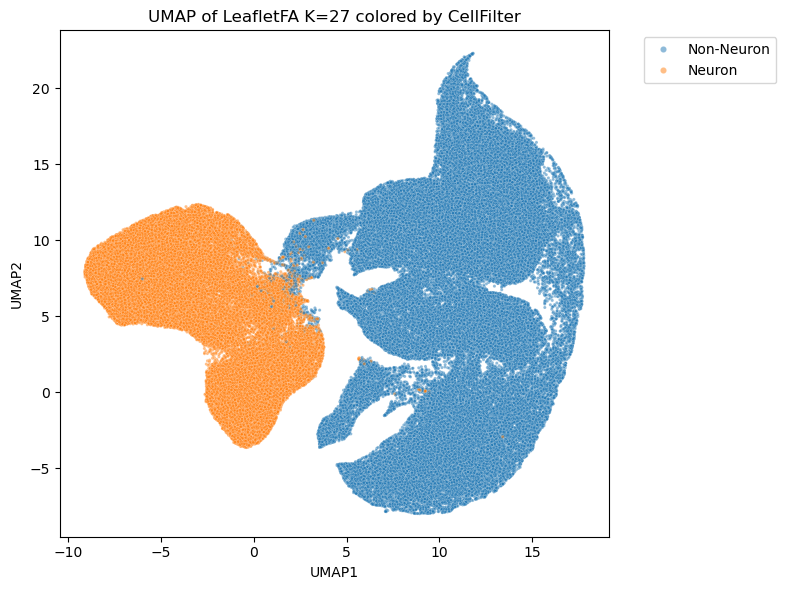

In [17]:
plot_umap(combined_obs, "CellFilter")

In [18]:
# make anndata object from combined_obs and combined_X
combined_adata = ad.AnnData(combined_X, obs=combined_obs)
# save combined_adata
combined_adata.write_h5ad("/gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/EasySci/combined_adata.h5ad", compression="gzip")

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [20]:
combined_adata.obs

,cell_id,broad_cell_type,age,cell_id_index,SOURCE,UMAP1,UMAP2,CellFilter
0,A10_B000120,EPITHELIAL CELL,18m,0,MOUSE_FOUNDATION,11.299564,5.515938,Non-Neuron
1,A10_B000126,KERATINOCYTE,3m,1,MOUSE_FOUNDATION,11.826104,2.873961,Non-Neuron
2,A10_B000127,MYELOID IMMUNE CELL,3m,2,MOUSE_FOUNDATION,14.704018,10.088587,Non-Neuron
3,A10_B000166,BASAL CELL,3m,3,MOUSE_FOUNDATION,11.607841,0.994850,Non-Neuron
4,A10_B000169,ENDOTHELIAL CELL,18m,4,MOUSE_FOUNDATION,13.676064,-3.660805,Non-Neuron
...,...,...,...,...,...,...,...,...
9916,Striatal_neurons_1_3mo_98,Striatal_neurons_1,3mo,9916,EASYSCI,-2.321028,6.686567,Neuron
9917,Striatal_neurons_1_5xFAD_1572,Striatal_neurons_1,5xFAD,9917,EASYSCI,-1.742229,7.943532,Neuron
9918,Striatal_neurons_1_5xFAD_928,Striatal_neurons_1,5xFAD,9918,EASYSCI,-0.906942,6.592748,Neuron
9919,Vascular_leptomeningeal_cells_5xFAD_103,Vascular_leptomeningeal_cells,5xFAD,9919,EASYSCI,6.620590,1.215714,Non-Neuron


In [26]:
# Append factor activties from combined_adata.X to combined_adata.obs with "Factor_0", "Factor_1", etc.
for i in range(combined_adata.X.shape[1]):
    combined_adata.obs[f"Factor_{i}"] = combined_adata.X[:, i]
combined_adata.obs

,cell_id,broad_cell_type,age,cell_id_index,SOURCE,UMAP1,UMAP2,CellFilter,Factor_0,Factor_1,...,Factor_17,Factor_18,Factor_19,Factor_20,Factor_21,Factor_22,Factor_23,Factor_24,Factor_25,Factor_26
0,A10_B000120,EPITHELIAL CELL,18m,0,MOUSE_FOUNDATION,11.299564,5.515938,Non-Neuron,0.033222,0.012989,...,0.003714,0.004370,0.006183,0.003152,0.003883,0.001483,0.002321,0.001825,0.001920,0.002346
1,A10_B000126,KERATINOCYTE,3m,1,MOUSE_FOUNDATION,11.826104,2.873961,Non-Neuron,0.020027,0.003902,...,0.006386,0.008904,0.007493,0.002028,0.002226,0.004402,0.005935,0.004830,0.007420,0.012648
2,A10_B000127,MYELOID IMMUNE CELL,3m,2,MOUSE_FOUNDATION,14.704018,10.088587,Non-Neuron,0.009822,0.003589,...,0.010118,0.149918,0.008602,0.006127,0.004532,0.002389,0.004109,0.005489,0.007270,0.002657
3,A10_B000166,BASAL CELL,3m,3,MOUSE_FOUNDATION,11.607841,0.994850,Non-Neuron,0.034746,0.010672,...,0.002283,0.001634,0.000172,0.000055,0.001591,0.002355,0.000866,0.001644,0.000535,0.366882
4,A10_B000169,ENDOTHELIAL CELL,18m,4,MOUSE_FOUNDATION,13.676064,-3.660805,Non-Neuron,0.001689,0.004391,...,0.002868,0.004861,0.001851,0.002134,0.003606,0.001110,0.000545,0.002956,0.001507,0.002442
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9916,Striatal_neurons_1_3mo_98,Striatal_neurons_1,3mo,9916,EASYSCI,-2.321028,6.686567,Neuron,0.004739,0.471414,...,0.009479,0.009485,0.003292,0.006240,0.007077,0.005326,0.005484,0.002982,0.003113,0.004228
9917,Striatal_neurons_1_5xFAD_1572,Striatal_neurons_1,5xFAD,9917,EASYSCI,-1.742229,7.943532,Neuron,0.059733,0.507822,...,0.040035,0.001960,0.007485,0.003656,0.009115,0.005357,0.002156,0.002567,0.002689,0.001290
9918,Striatal_neurons_1_5xFAD_928,Striatal_neurons_1,5xFAD,9918,EASYSCI,-0.906942,6.592748,Neuron,0.013218,0.385357,...,0.005249,0.003131,0.009627,0.006399,0.006417,0.010219,0.007632,0.002867,0.004722,0.004166
9919,Vascular_leptomeningeal_cells_5xFAD_103,Vascular_leptomeningeal_cells,5xFAD,9919,EASYSCI,6.620590,1.215714,Non-Neuron,0.073601,0.040127,...,0.008822,0.025755,0.008898,0.017828,0.012056,0.018469,0.010687,0.022458,0.013414,0.024756


In [34]:
# Standardize inconsistent age labels
combined_adata.obs["age"] = combined_adata.obs["age"].replace({
    "3mo": "3m",
    "6mo": "6m",
    "21mo": "21m"
})


/scratch/ipykernel_3172259/2655924051.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  combined_adata.obs["age"] = combined_adata.obs["age"].replace({


In [38]:
combined_adata.obs_names_make_unique()
combined_adata.obs["age"].unique()

['18m', '3m', '24m', '2m', '5xFAD', 'APOE4_TREM2', '21m', '6m']
Categories (8, object): ['2m', '3m', '5xFAD', '6m', '18m', '21m', '24m', 'APOE4_TREM2']

In [54]:
def plot_factor_activities_by_age(adata, factor_name, save_path=None):
    import seaborn as sns
    import matplotlib.pyplot as plt
    import pandas as pd

    # Standardize age labels
    adata.obs["age"] = adata.obs["age"].replace({
        "3mo": "3m", "6mo": "6m", "21mo": "21m"
    })

    # Define color map
    source_palette = {
        "MOUSE_FOUNDATION": "#1f77b4",  # blue
        "EASYSCI": "#ff7f0e"            # orange
    }

    sources = adata.obs["SOURCE"].unique()

    # Create subplot manually (not sns.catplot) so we can control per-axis logic
    n_sources = len(sources)
    fig, axes = plt.subplots(1, n_sources, figsize=(6 * n_sources, 5), sharey=True)

    if n_sources == 1:
        axes = [axes]  # make iterable

    for ax, source in zip(axes, sources):
        data_sub = adata.obs[adata.obs["SOURCE"] == source].copy()

        # Get actual age groups present in this source
        present_ages = data_sub["age"].unique()
        present_ages = sorted(present_ages, key=lambda x: int(x.strip('m').replace("xFAD", "100").replace("APOE4_TREM2", "101")))  # crude sort

        # Draw violin
        sns.violinplot(
            data=data_sub,
            x="age",
            y=factor_name,
            order=present_ages,
            ax=ax,
            color=source_palette.get(source, "gray"),
            cut=0,
            inner="box",
            linewidth=0.7,
            density_norm="width"
        )

        # Annotate medians as text
        medians = (
            data_sub.groupby("age")[factor_name]
            .median()
            .reindex(present_ages)
        )

        for i, (age, val) in enumerate(medians.items()):
            if pd.notnull(val):
                ax.text(i, val + 0.01, f"{val:.2f}", ha='center', va='bottom', fontsize=9, color='black')

        ax.set_title(source, fontsize=13)
        ax.set_xlabel("Age Group", fontsize=11)
        ax.set_ylabel("Factor Activity", fontsize=11)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

    fig.suptitle(f"{factor_name} Activity by Age Group (Faceted by Source)", fontsize=15, weight='bold')
    fig.tight_layout(rect=[0, 0, 1, 0.92])  # leave space for title

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


/scratch/ipykernel_3172259/438598631.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_sub.groupby("age")[factor_name]
/scratch/ipykernel_3172259/438598631.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
/scratch/ipykernel_3172259/438598631.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_sub.groupby("age")[factor_name]
/scratch/ipykernel_3172259/438598631.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks

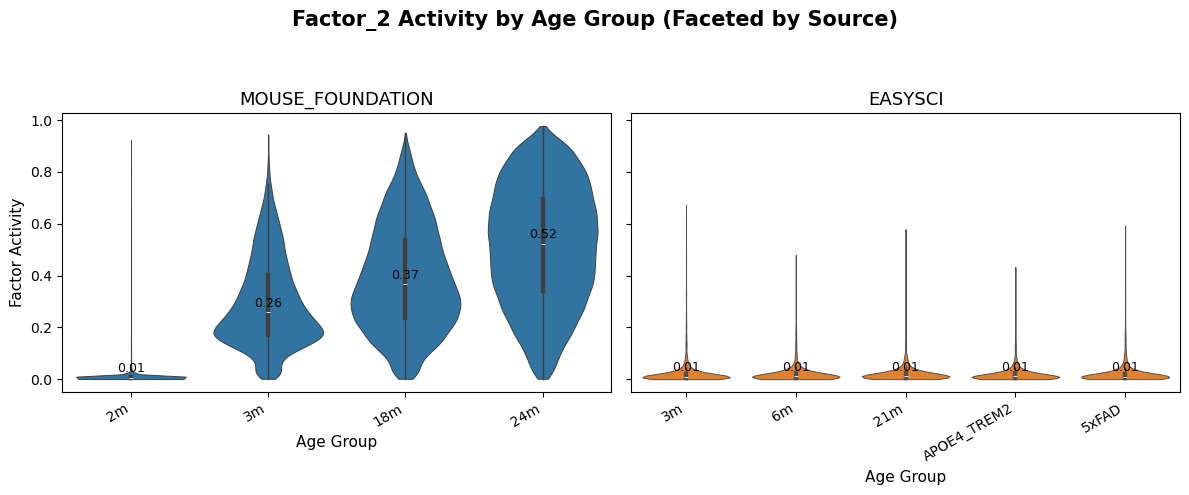

In [55]:
factor_cols = [col for col in combined_adata.obs.columns if col.startswith("Factor_")]
# test on just Factor_0
plot_factor_activities_by_age(combined_adata, "Factor_2")

In [70]:
neuron_labels = combined_adata.obs["broad_cell_type"].unique()
neuron_labels = [x for x in neuron_labels if "neuron" in str(x).lower()]
combined_adata_neuron = combined_adata[combined_adata.obs["broad_cell_type"].isin(neuron_labels)].copy()
combined_adata_neuron.obs

,cell_id,broad_cell_type,age,cell_id_index,SOURCE,UMAP1,UMAP2,CellFilter,Factor_0,Factor_1,...,Factor_17,Factor_18,Factor_19,Factor_20,Factor_21,Factor_22,Factor_23,Factor_24,Factor_25,Factor_26
202,A10_B003903,NEURON,24m,202,MOUSE_FOUNDATION,2.251777,8.095181,Non-Neuron,0.000939,0.049355,...,0.010379,0.004377,0.005803,0.002155,0.003561,0.001406,0.005058,0.004236,0.005377,0.004072
268,A10_MAA000641,NEURON,3m,268,MOUSE_FOUNDATION,11.519341,3.404215,Non-Neuron,0.009568,0.027161,...,0.019544,0.027093,0.008328,0.006741,0.009220,0.003582,0.011700,0.014813,0.015876,0.008783
365,A11_B000922,NEURON,24m,365,MOUSE_FOUNDATION,8.988845,-3.607529,Non-Neuron,0.025652,0.014223,...,0.004092,0.019157,0.006682,0.003403,0.004730,0.013692,0.011066,0.004519,0.005322,0.007327
529,A11_D045326,NEURON,18m,529,MOUSE_FOUNDATION,1.270887,5.375568,Non-Neuron,0.000600,0.177718,...,0.001335,0.001630,0.001050,0.001080,0.001462,0.000922,0.000579,0.000310,0.001086,0.000352
551,A11_MAA000564,NEURON,3m,551,MOUSE_FOUNDATION,-4.512210,10.243959,Non-Neuron,0.002482,0.606444,...,0.002291,0.007149,0.001750,0.002277,0.004003,0.000838,0.000890,0.000830,0.001459,0.000608
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9903-1,OB_neurons_1_6mo_857,OB_neurons_1,6m,9903,EASYSCI,1.106219,5.443522,Neuron,0.043734,0.131068,...,0.211602,0.017815,0.031721,0.023095,0.026469,0.010753,0.012963,0.011645,0.009185,0.008275
9915-1,Striatal_neurons_1_21mo_820,Striatal_neurons_1,21m,9915,EASYSCI,-1.638417,6.986763,Neuron,0.030030,0.527364,...,0.021161,0.013084,0.013561,0.012042,0.012538,0.010963,0.005547,0.004008,0.003705,0.005241
9916-1,Striatal_neurons_1_3mo_98,Striatal_neurons_1,3m,9916,EASYSCI,-2.321028,6.686567,Neuron,0.004739,0.471414,...,0.009479,0.009485,0.003292,0.006240,0.007077,0.005326,0.005484,0.002982,0.003113,0.004228
9917-1,Striatal_neurons_1_5xFAD_1572,Striatal_neurons_1,5xFAD,9917,EASYSCI,-1.742229,7.943532,Neuron,0.059733,0.507822,...,0.040035,0.001960,0.007485,0.003656,0.009115,0.005357,0.002156,0.002567,0.002689,0.001290


In [ ]:
# maybe just need to hone in on neuron related factors? 
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd

def fit_multiclass_logreg_on_factors(adata, factor_prefix="Factor_", target_col="age"):
    # Prepare inputs
    df = adata.obs.copy()
    df[target_col] = df[target_col].replace({"3mo": "3m", "6mo": "6m", "21mo": "21m"})

    X = df[[col for col in df.columns if col.startswith(factor_prefix)]].copy()
    y = df[target_col]

    # Optional: scale features for numerical stability
    X_scaled = StandardScaler().fit_transform(X)

    # Fit multinomial logistic regression
    clf = LogisticRegression(multi_class="multinomial", solver="lbfgs", max_iter=1000)
    clf.fit(X_scaled, y)

    # Output: one row per class, one column per factor
    coef_df = pd.DataFrame(
        clf.coef_,
        index=clf.classes_,
        columns=X.columns
    )

    return coef_df

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

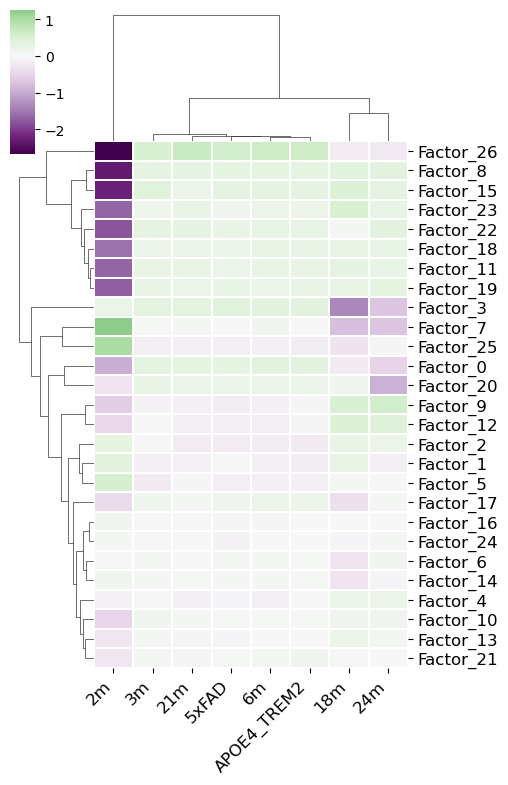

In [ ]:
coef_df = fit_multiclass_logreg_on_factors(combined_adata_neuron)
g1 = sns.clustermap(coef_df.T, cmap="PRGn", center=0, figsize=(5, 8), linewidths=0.1)

# Extract factor (row) order from first clustermap
factor_order = g1.dendrogram_row.reordered_ind
ordered_factors = coef_df.T.index[factor_order]

# increase font size of x y tick marks 
plt.setp(g1.ax_heatmap.get_xticklabels(), rotation=45, ha='right', fontsize=12)
plt.setp(g1.ax_heatmap.get_yticklabels(), rotation=0, fontsize=12)

/scratch/ipykernel_3172259/3399623008.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_activity = combined_adata_neuron.obs.groupby("age")[factor_cols].median()


[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

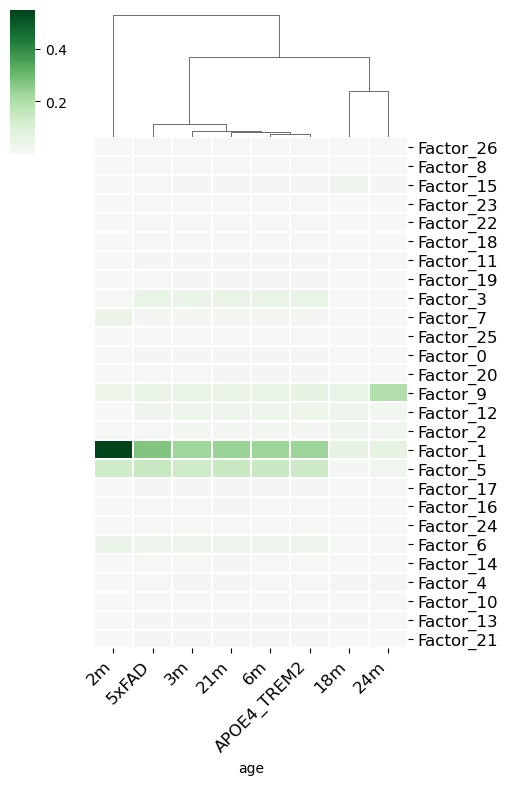

In [85]:
# Find factor columns
factor_cols = [col for col in combined_adata_neuron.obs.columns if col.startswith("Factor_")]

# Group by age and compute median for each factor
median_activity = combined_adata_neuron.obs.groupby("age")[factor_cols].median()

# Reorder rows (factors) in median activity
ordered_median_activity = median_activity.T.loc[ordered_factors]

# Now plot without reclustering rows (just cluster columns/ages)
g2 = sns.clustermap(
    ordered_median_activity,
    cmap="PRGn",
    center=0,
    row_cluster=False,
    col_cluster=True,
    linewidths=0.1,
    figsize=(5, 8)
)

plt.setp(g2.ax_heatmap.get_xticklabels(), rotation=45, ha='right', fontsize=12)
plt.setp(g2.ax_heatmap.get_yticklabels(), rotation=0, fontsize=12)


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

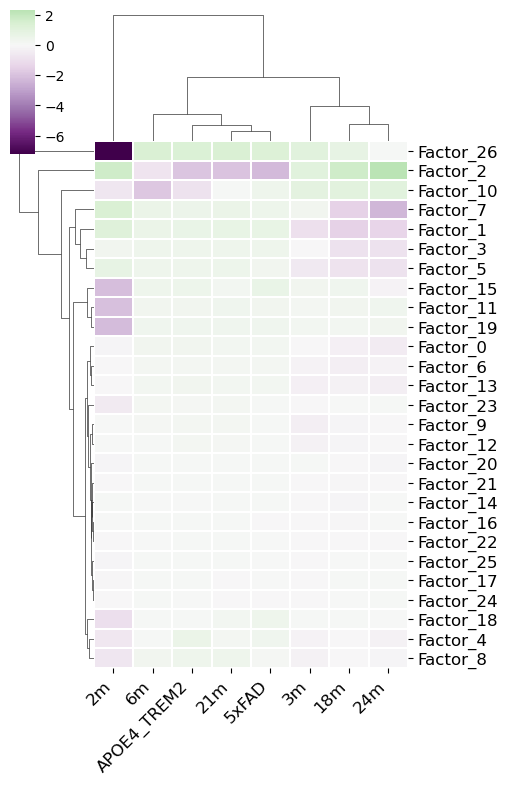

In [87]:
coef_df = fit_multiclass_logreg_on_factors(combined_adata)
g1 = sns.clustermap(coef_df.T, cmap="PRGn", center=0, figsize=(5, 8), linewidths=0.1)

# Extract factor (row) order from first clustermap
factor_order = g1.dendrogram_row.reordered_ind
ordered_factors = coef_df.T.index[factor_order]

# increase font size of x y tick marks 
plt.setp(g1.ax_heatmap.get_xticklabels(), rotation=45, ha='right', fontsize=12)
plt.setp(g1.ax_heatmap.get_yticklabels(), rotation=0, fontsize=12)

/scratch/ipykernel_3172259/882918515.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_activity = combined_adata.obs.groupby("age")[factor_cols].median()


[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

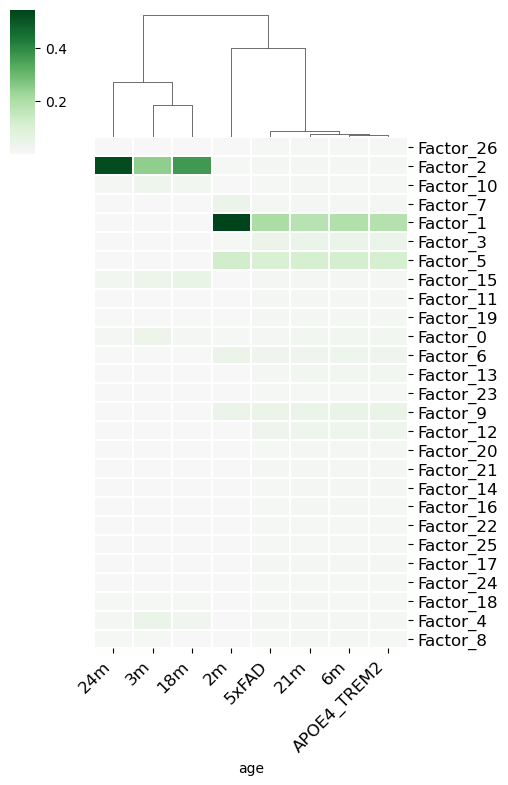

In [88]:
# Find factor columns
factor_cols = [col for col in combined_adata.obs.columns if col.startswith("Factor_")]

# Group by age and compute median for each factor
median_activity = combined_adata.obs.groupby("age")[factor_cols].median()

# Reorder rows (factors) in median activity
ordered_median_activity = median_activity.T.loc[ordered_factors]

# Now plot without reclustering rows (just cluster columns/ages)
g2 = sns.clustermap(
    ordered_median_activity,
    cmap="PRGn",
    center=0,
    row_cluster=False,
    col_cluster=True,
    linewidths=0.1,
    figsize=(5, 8)
)

plt.setp(g2.ax_heatmap.get_xticklabels(), rotation=45, ha='right', fontsize=12)
plt.setp(g2.ax_heatmap.get_yticklabels(), rotation=0, fontsize=12)

In [93]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import pandas as pd

def fit_multiclass_logreg_with_interactions(adata, factor_prefix="Factor_", target="age", interaction_with="broad_cell_type"):
    df = adata.obs.copy()

    # Clean up age labels
    df[target] = df[target].replace({"3mo": "3m", "6mo": "6m", "21mo": "21m"})

    # Make sure age is a proper categorical (not object/str)
    df[target] = pd.Categorical(df[target])

    # Ensure SOURCE is categorical too
    df[interaction_with] = pd.Categorical(df[interaction_with])

    # Build the model formula
    factor_cols = [col for col in df.columns if col.startswith(factor_prefix)]
    formula_terms = " + ".join(factor_cols)
    formula = f"{target} ~ ({formula_terms}) * {interaction_with}"

    # Use MNLogit from statsmodels.api with dmatrices to avoid formula parsing issues
    import patsy
    y, X = patsy.dmatrices(formula, data=df, return_type='dataframe')

    # Flatten y to 1D vector of category codes
    y_flat = df[target].cat.codes

    model = sm.MNLogit(y_flat, X).fit(disp=False)
    return model, df[target].cat.categories



In [94]:
model, age_categories = fit_multiclass_logreg_with_interactions(combined_adata_neuron)
coef_df = pd.DataFrame(model.params.T)
coef_df.columns = [f"vs_{c}" for c in age_categories[1:]]  # first is baseline

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/statsmodels/discrete/discrete_model.py:3027: RuntimeWarning: overflow encountered in exp
  eXB = np.column_stack((np.ones(len(X)), np.exp(X)))
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/statsmodels/discrete/discrete_model.py:3028: RuntimeWarning: invalid value encountered in divide
  return eXB/eXB.sum(1)[:,None]


KeyboardInterrupt: 

In [ ]:
g1 = sns.clustermap(coef_df, cmap="PRGn", center=0, figsize=(5, 8), linewidths=0.1)
plt.setp(g1.ax_heatmap.get_xticklabels(), rotation=45, ha='right', fontsize=12)
plt.setp(g1.ax_heatmap.get_yticklabels(), rotation=0, fontsize=12)